# ДЗ1. CLAP. Обучение проекции из аудио в текстовое пространство CLIP

**Описание задания**

В этом задании вы построите упрощённый вариант модели CLAP (Contrastive Language-Audio Pretraining):

- аудио прогоняется через предобученный аудио-энкодер (например, `LanguageBindAudio`, `CNN14/16` или другой);
- текстовое описание пропускается через предобученный текстовый энкодер CLIP;
- поверх аудио-векторов обучается линейный адаптер, который отображает аудио в то же пространство, что и текстовые эмбеддинги CLIP;
- обучение идёт по *контрастивному лоссу*, все энкодеры заморожены, обучаются только параметры аудио-проекции (и, при желании, температура в лоссе);
- качество полученного аудио-текстового пространства оценивается на задаче классификации / retrieval аудио по текстам на `AudioCaps`.

Идея оценки: если всё сделано правильно, для аудио и его описания косинусное сходство эмбеддингов будет выше, чем для аудио и нерелевантных текстов.


**Формулировка задач**

0. Выбор аудио-энкодера.
   Выберите и обоснуйте предобученный аудио-энбеддер:  
   - `LanguageBindAudio`,  
   - или CNN-модель (например, PANNs CNN14/16),  
   - или другой открытый аудио-энкодер, который выдаёт фиксированный эмбеддинг.

1. Подсчёт эмбеддингов.
   - Посчитайте аудио-векторы для всех аудио из `AudioCaps` с помощью выбранного энкодера.  
   - Посчитайте текстовые векторы для подписей с помощью `CLIP text encoder`.

2. Линейная аудио-проекция.
   - Реализуйте модель `AudioProjection`, переводящую аудио-эмбеддинг в размерность текстового эмбеддинга CLIP.

3. Контрастивное обучение.
   - Обучите аудио-проекцию на датасете `AudioCaps` по схеме аудио ↔ текст с контрастивным лоссом.  
   - Аудио-энкодер и CLIP должны быть полностью заморожены.

4. Оценка качества.
   - Оцените качество полученного аудио-текстового пространства на задаче классификации/ретривала аудио:  
     для каждого аудио найдите наиболее похожую текстовую подпись в батче/валидации и посчитайте `accuracy@1/3/10`.  
   - Сравните результаты с *случайным бейзлайном*.


### Сеттинг

> Подготовьте все необходимые импорты и загрузите необходимые данные.

In [84]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nickkar30_audiocaps_path = kagglehub.dataset_download('nickkar30/audiocaps')


Using Colab cache for faster access to the 'audiocaps' dataset.


In [85]:
import os

print(os.listdir(nickkar30_audiocaps_path + '/audiocaps'))

['audiocaps_val_new.tsv', 'val_texts.json', 'audio', 'audiocaps_test_new.tsv', 'test_texts.json', 'audiocaps_val.tsv', 'audiocaps_train.tsv', 'audiocaps_test.tsv']


### Задание 1. Подготовка аудио- и текстовых энкодеров (2 балла)

В этом задании вам нужно:

1. Выбрать аудио-энкодер и инициализировать его.
2. Инициализировать текстовый энкодер CLIP. Вы свободны выбирать самостоятельно, какой имеено.
3. Заморозить параметры обоих энкодеров (мы не дообучаем их, а учим только линейный адаптер).

Вы можете:

* использовать `LanguageBindAudio` (потребует установки репозитория и зависимостей);
* или подставить свою аудио-модель (главное - чтобы на выходе был вектор фиксированной размерности).


In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import pickle
import os
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [87]:
!pip install torchaudio
!pip install panns-inference

In [88]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-he3hvlle
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-he3hvlle
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [89]:
# Для аудио-энкодера выберем CNN14, поскольку в чате написали, что он легче всего ставится без проблем с LanguageBindAudio
# Для текстового энкодера используем CLIP

from panns_inference import AudioTagging, labels
import clip

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import pickle
from tqdm import tqdm
import librosa

class AudioTextEncoders:
    def __init__(self):
        self.audio_encoder = None
        self.text_encoder = None
        self.text_processor = None

    def load_audio_encoder(self):
        """Загрузка аудио-энкодера CNN14 из PANNs"""
        try:
            from panns_inference import AudioTagging
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            self.audio_encoder = AudioTagging(checkpoint_path=None, device=device)
            print("Аудио-энкодер PANNs успешно загружен")

        except Exception as e:
            print(f"Ошибка при загрузке PANNs: {e}")

    def extract_audio_embedding_panns(self, audio_tensor):
        """Извлечение эмбеддинга с помощью PANNs"""
        try:
            with torch.no_grad():
                # PANNs возвращает (clipwise_output, embedding)
                _, embedding = self.audio_encoder.inference(audio_tensor)
            # Убираем лишнюю размерность: [1, 2048] -> [2048]
            return embedding.squeeze(0)
        except Exception as e:
            print(f"Ошибка при извлечении эмбеддинга PANNs: {e}")
            return None

    def load_text_encoder(self):
        """Загрузка текстового энкодера CLIP"""
        try:
            import clip
            device = "cuda" if torch.cuda.is_available() else "cpu"
            model, preprocess = clip.load("ViT-B/32", device=device)
            self.text_encoder = model
            self.text_processor = clip  # Сохраняем сам модуль clip для tokenize
            print("Текстовый энкодер CLIP успешно загружен")

        except ImportError:
            print("CLIP не установлен, устанавливаем...")
            !pip install git+https://github.com/openai/CLIP.git
            import clip
            device = "cuda" if torch.cuda.is_available() else "cpu"
            model, preprocess = clip.load("ViT-B/32", device=device)
            self.text_encoder = model
            self.text_processor = clip

    def get_audio_embedding_dim(self):
        """Получить размерность аудио-эмбеддинга"""
        return 2048  # PANNs CNN14 embedding dimension

    def get_text_embedding_dim(self):
        """Получить размерность текстового эмбеддинга"""
        return 512  # CLIP ViT-B/32

In [90]:
import torchaudio
import torch.nn.functional as F

# Инициализация и запуск
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Инициализируем энкодеры
print("Инициализация энкодеров...")
encoders = AudioTextEncoders()
encoders.load_audio_encoder()
encoders.load_text_encoder()

print(f"Аудио-энкодер загружен, размерность выхода: {encoders.get_audio_embedding_dim()}")
print(f"Текстовый энкодер загружен, размерность выхода: {encoders.get_text_embedding_dim()}")

Using device: cuda
Инициализация энкодеров...
Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
GPU number: 1
Аудио-энкодер PANNs успешно загружен
Текстовый энкодер CLIP успешно загружен
Аудио-энкодер загружен, размерность выхода: 2048
Текстовый энкодер загружен, размерность выхода: 512


### Задание 2. Предподсчёт аудио- и текстовых эмбеддингов (3 балла)

> Важный момент, который пригодится вам и в других домашних.

Чтобы не тратить время на многократный прогон энкодеров при обучении, следует:

1. Предварительно посчитывать аудио-эмбеддинги для каждого `.flac` в train/val/test.
2. Записывать их в файл формата `pickle` (например), где ключ - имя файла, значение - numpy-вектор.
3. Аналогично посчитать текстовые эмбеддинги для подписей через CLIP и совместить их с аудио.

Рекомендуемая структура:

* функция `extract_audio_vectors_with_checkpointing(...)` - обходит файлы, считает эмбеддинги, периодически делает чекпоинты;
* функция `extract_text_embeddings(texts, clip_model, clip_processor)` - возвращает список текстовых эмбеддингов;
* функция `process_dataset(...)` - читает `.tsv`, мержит аудио-эмбеддинги и текстовые, сохраняет список словарей вида  
  `{"uniq_id": ..., "audio_embedding": ..., "text_embedding": ...}` в pickle.

> Вы вольны отходить от предлагаемой структуры.

In [91]:
class EmbeddingExtractor:
    def __init__(self, encoders, base_audio_path):
        self.encoders = encoders
        self.audio_cache = {}
        self.text_cache = {}
        self.base_audio_path = base_audio_path

    def get_full_audio_path(self, audio_rel_path):
        """Получить полный путь к аудио файлу"""
        return os.path.join(self.base_audio_path, audio_rel_path)

    def load_and_preprocess_audio(self, audio_path, target_sr=32000, duration=10):
        """Загрузка и предобработка аудио файла для PANNs"""
        try:
            full_audio_path = self.get_full_audio_path(audio_path)

            # Проверяем существование файла
            if not os.path.exists(full_audio_path):
                print(f"Файл не найден: {full_audio_path}")
                return None

            # Загружаем аудио с sample rate 32000 (требуется для PANNs)
            audio, sr = librosa.load(full_audio_path, sr=target_sr, duration=duration)

            # Если аудио короче duration, дополняем нулями
            target_length = target_sr * duration
            if len(audio) < target_length:
                padding = target_length - len(audio)
                audio = np.pad(audio, (0, padding))
            elif len(audio) > target_length:
                audio = audio[:target_length]

            # Нормализуем
            if np.max(np.abs(audio)) > 0:
                audio = audio / np.max(np.abs(audio))

            return torch.tensor(audio).float().unsqueeze(0)

        except Exception as e:
            print(f"Ошибка при загрузке аудио {audio_path}: {e}")
            return None

    def extract_audio_embedding(self, audio_path):
        """Извлечение аудио-эмбеддинга из реального файла с использованием PANNs"""
        if audio_path in self.audio_cache:
            return self.audio_cache[audio_path]

        try:
            # Загружаем и предобрабатываем аудио
            audio_tensor = self.load_and_preprocess_audio(audio_path)

            if audio_tensor is None:
                print(f"Не удалось загрузить аудио: {audio_path}")
                return None

            # Получаем эмбеддинг через PANNs
            audio_embedding = self.encoders.extract_audio_embedding_panns(audio_tensor)

            if audio_embedding is None:
                print(f"Не удалось извлечь эмбеддинг для: {audio_path}")
                return None

            self.audio_cache[audio_path] = audio_embedding
            return audio_embedding

        except Exception as e:
            print(f"Ошибка при обработке аудио {audio_path}: {e}")
            return None

    def extract_text_embedding(self, text):
        """Извлечение текстового эмбеддинга с использованием CLIP"""
        text_key = text  # Используем сам текст как ключ для простоты
        if text_key in self.text_cache:
            return self.text_cache[text_key]

        try:
            with torch.no_grad():
                # Правильное использование CLIP для кодирования текста
                text_tokens = self.encoders.text_processor.tokenize([text]).to(device)
                text_embedding = self.encoders.text_encoder.encode_text(text_tokens)
                # Убираем лишнюю размерность: [1, 512] -> [512]
                text_embedding = text_embedding.squeeze(0)
            self.text_cache[text_key] = text_embedding
            return text_embedding

        except Exception as e:
            print(f"Ошибка при обработке текста '{text}': {e}")
            print(f"Тип text: {type(text)}, значение: {text}")
            return None

    def extract_audio_vectors_with_checkpointing(self, audio_files, checkpoint_file="audio_embeddings.pkl", batch_size=8):
        """Пакетное извлечение аудио-эмбеддингов с чекпоинтами"""
        # Если файл с чекпоинтом существует, загружаем из него
        if os.path.exists(checkpoint_file):
            try:
                with open(checkpoint_file, 'rb') as f:
                    loaded_cache = pickle.load(f)
                for key in loaded_cache:
                    if loaded_cache[key] is not None:
                        loaded_cache[key] = loaded_cache[key].to(device)
                self.audio_cache.update(loaded_cache)
                print(f"Загружены эмбеддинги для {len(loaded_cache)} аудиофайлов из {checkpoint_file}")

                # Проверяем, есть ли еще файлы для обработки
                remaining_files = [f for f in audio_files if f not in self.audio_cache]
                if not remaining_files:
                    print("Все аудиофайлы уже обработаны!")
                    return self.audio_cache
                else:
                    print(f"Осталось обработать {len(remaining_files)} файлов")
                    audio_files = remaining_files
            except Exception as e:
                print(f"Ошибка при загрузке чекпоинта: {e}")
                print("Начинаем обработку заново...")

        print(f"Извлечение эмбеддингов для {len(audio_files)} аудиофайлов...")

        successful_extractions = 0
        for i in tqdm(range(0, len(audio_files), batch_size)):
            batch_files = audio_files[i:i+batch_size]

            for audio_file in batch_files:
                if audio_file not in self.audio_cache:  # Проверяем, не обработан ли уже
                    embedding = self.extract_audio_embedding(audio_file)
                    if embedding is not None:
                        successful_extractions += 1
                    else:
                        # Сохраняем None для неудачных попыток, чтобы не пытаться снова
                        self.audio_cache[audio_file] = None

            # Сохраняем чекпоинт каждые 50 файлов
            if i % 50 == 0 and i > 0:
                with open(checkpoint_file, 'wb') as f:
                    # Сохраняем только успешные эмбеддинги (не None)
                    successful_cache = {k: v for k, v in self.audio_cache.items() if v is not None}
                    pickle.dump(successful_cache, f)
                print(f"Промежуточное сохранение: {successful_extractions}/{i+batch_size} успешных извлечений")

        # Финальное сохранение
        successful_cache = {k: v for k, v in self.audio_cache.items() if v is not None}
        with open(checkpoint_file, 'wb') as f:
            pickle.dump(successful_cache, f)

        print(f"Успешно извлечено эмбеддингов: {successful_extractions}/{len(audio_files)}")
        return successful_cache

    def extract_text_embeddings(self, texts, checkpoint_file="text_embeddings.pkl"):
        """Пакетное извлечение текстовых эмбеддингов"""
        # Если файл с чекпоинтом существует, загружаем из него
        if os.path.exists(checkpoint_file):
            try:
                with open(checkpoint_file, 'rb') as f:
                    loaded_cache = pickle.load(f)
                self.text_cache.update(loaded_cache)
                print(f"Загружены эмбеддинги для {len(loaded_cache)} текстов из {checkpoint_file}")

                # Проверяем, есть ли еще тексты для обработки
                remaining_texts = [t for t in texts if t not in self.text_cache]
                if not remaining_texts:
                    print("Все тексты уже обработаны!")
                    return self.text_cache
                else:
                    print(f"Осталось обработать {len(remaining_texts)} текстов")
                    texts = remaining_texts
            except Exception as e:
                print(f"Ошибка при загрузке чекпоинта: {e}")
                print("Начинаем обработку заново...")

        print(f"Извлечение эмбеддингов для {len(texts)} текстов...")

        successful_extractions = 0
        for i, text in enumerate(tqdm(texts)):
            if text not in self.text_cache:  # Проверяем, не обработан ли уже
                embedding = self.extract_text_embedding(text)
                if embedding is not None:
                    successful_extractions += 1
                else:
                    # Сохраняем None для неудачных попыток
                    self.text_cache[text] = None

            # Сохраняем чекпоинт каждые 100 текстов
            if i % 100 == 0 and i > 0:
                successful_cache = {k: v for k, v in self.text_cache.items() if v is not None}
                with open(checkpoint_file, 'wb') as f:
                    pickle.dump(successful_cache, f)
                print(f"Промежуточное сохранение текстов: {successful_extractions}/{i+1} успешных извлечений")

        # Сохраняем только успешные эмбеддинги
        successful_cache = {k: v for k, v in self.text_cache.items() if v is not None}
        with open(checkpoint_file, 'wb') as f:
            pickle.dump(successful_cache, f)

        print(f"Успешно извлечено текстовых эмбеддингов: {successful_extractions}/{len(texts)}")
        return successful_cache

    def load_audiocaps_data(self, tsv_file):
        """Загрузка данных из AudioCaps TSV файла"""
        print(f"Загрузка данных из {tsv_file}...")
        df = pd.read_csv(tsv_file, sep='\t')

        # Проверяем наличие необходимых колонок
        required_columns = ['uniq_id', 'audio', 'text']
        missing_columns = [col for col in required_columns if col not in df.columns]

        if missing_columns:
            raise ValueError(f"Отсутствуют необходимые колонки: {missing_columns}")

        print(f"Загружено {len(df)} записей")

        # Проверяем существование некоторых аудио файлов
        print("\nПроверка существования аудио файлов (первые 5):")
        sample_checked = 0
        existing_files = 0
        for idx, row in df.head(5).iterrows():
            full_path = self.get_full_audio_path(row['audio'])
            exists = os.path.exists(full_path)
            print(f"  {row['audio']} -> {full_path} : {'✅ Существует' if exists else '❌ Не существует'}")
            if exists:
                existing_files += 1
            sample_checked += 1

        if sample_checked > 0:
            print(f"Из проверенных {sample_checked} файлов существует: {existing_files}")

        return df

    def process_dataset(self, tsv_file, output_file="dataset_embeddings.pkl", sample_size=None):
        """Обработка всего датасета и сохранение эмбеддингов"""
        # Загружаем данные из TSV файла
        df = self.load_audiocaps_data(tsv_file)

        # Если указан sample_size, берем только часть данных
        if sample_size and sample_size < len(df):
            df = df.sample(sample_size, random_state=42)
            print(f"Взята выборка из {sample_size} записей")

        # Получаем списки аудиофайлов и текстов
        audio_files = df['audio'].tolist()
        texts = df['text'].tolist()
        uniq_ids = df['uniq_id'].tolist()

        # Извлекаем эмбеддинги
        print("Извлечение аудио-эмбеддингов...")
        audio_embeddings = self.extract_audio_vectors_with_checkpointing(audio_files)

        print("Извлечение текстовых эмбеддингов...")
        text_embeddings = self.extract_text_embeddings(texts)

        # Собираем данные
        dataset_embeddings = []
        successful_count = 0

        for i, (uniq_id, audio_file, text) in enumerate(zip(uniq_ids, audio_files, texts)):
            # Проверяем, что оба эмбеддинга успешно извлечены
            audio_emb = audio_embeddings.get(audio_file)
            text_emb = text_embeddings.get(text)

            if audio_emb is not None and text_emb is not None:
                dataset_embeddings.append({
                    "uniq_id": uniq_id,
                    "audio_file": audio_file,
                    "text": text,
                    "audio_embedding": audio_emb,
                    "text_embedding": text_emb
                })
                successful_count += 1

            if i % 1000 == 0 and i > 0:
                print(f"Обработано {i}/{len(df)} записей, успешно: {successful_count}")

        # Сохраняем
        with open(output_file, 'wb') as f:
            pickle.dump(dataset_embeddings, f)

        print(f"Сохранено {successful_count} успешных примеров в {output_file}")
        print(f"Успешных записей: {successful_count}/{len(df)} ({successful_count/len(df)*500:.1f}%)")

        # Показываем пример данных
        if dataset_embeddings:
            print("\nПример обработанных данных:")
            sample = dataset_embeddings[0]
            print(f"  ID: {sample['uniq_id']}")
            print(f"  Аудио файл: {sample['audio_file']}")
            print(f"  Текст: {sample['text']}")
            print(f"  Размер аудио-эмбеддинга: {sample['audio_embedding'].shape}")
            print(f"  Размер текстового эмбеддинга: {sample['text_embedding'].shape}")

        return dataset_embeddings


In [92]:
# Создаем экстрактор
extractor = EmbeddingExtractor(
    encoders=encoders,
    base_audio_path=nickkar30_audiocaps_path
)

In [103]:
# Обрабатываем тренировочный датасет
dataset_embeddings = extractor.process_dataset(
    tsv_file=os.path.join(nickkar30_audiocaps_path, 'audiocaps/audiocaps_train.tsv'),
    output_file="audiocaps_embeddings.pkl"
)

Загрузка данных из /kaggle/input/audiocaps/audiocaps/audiocaps_train.tsv...
Загружено 49490 записей

Проверка существования аудио файлов (первые 5):
  audiocaps/audio/train/0.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/0.flac : ✅ Существует
  audiocaps/audio/train/1.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/1.flac : ✅ Существует
  audiocaps/audio/train/2.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/2.flac : ✅ Существует
  audiocaps/audio/train/3.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/3.flac : ✅ Существует
  audiocaps/audio/train/4.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/4.flac : ✅ Существует
Из проверенных 5 файлов существует: 5
Извлечение аудио-эмбеддингов...
Ошибка при загрузке чекпоинта: 'numpy.ndarray' object has no attribute 'to'
Начинаем обработку заново...
Извлечение эмбеддингов для 49490 аудиофайлов...


  0%|          | 26/6187 [00:05<22:18,  4.60it/s]

Промежуточное сохранение: 208/208 успешных извлечений


  1%|          | 51/6187 [00:11<22:38,  4.52it/s]

Промежуточное сохранение: 408/408 успешных извлечений


...

Промежуточное сохранение текстов: 45150/48701 успешных извлечений


100%|█████████▉| 48823/48872 [32:28<00:04, 10.46it/s]

Промежуточное сохранение текстов: 45237/48801 успешных извлечений


100%|██████████| 48872/48872 [32:28<00:00, 25.08it/s]


Успешно извлечено текстовых эмбеддингов: 45301/48872
Обработано 100/49490 записей, успешно: 101
Обработано 200/49490 записей, успешно: 201
Обработано 300/49490 записей, успешно: 301
Обработано 400/49490 записей, успешно: 401
Обработано 500/49490 записей, успешно: 501
Обработано 600/49490 записей, успешно: 601
Обработано 700/49490 записей, успешно: 701
Обработано 800/49490 записей, успешно: 801
Обработано 900/49490 записей, успешно: 901
Обработано 1000/49490 записей, успешно: 1001
Обработано 1100/49490 записей, успешно: 1101
Обработано 1200/49490 записей, успешно: 1201
Обработано 1300/49490 записей, успешно: 1301
Обработано 1400/49490 записей, успешно: 1401
Обработано 1500/49490 записей, успешно: 1501
Обработано 1600/49490 записей, успешно: 1601
Обработано 1700/49490 записей, успешно: 1701
Обработано 1800/49490 записей, успешно: 1801
Обработано 1900/49490 записей, успешно: 1901
Обработано 2000/49490 записей, успешно: 2001
Обработано 2100/49490 записей, успешно: 2101
Обработано 2200/4949

### Задание 3. Линейный аудио-адаптер и контрастивный лосс (3 балла)


Теперь, когда у нас есть пары *audio_embedding, text_embedding*, реализуем:

1. Класс `AudioTextDataset`, который читает pickle с комбинированными эмбеддингами.
2. Линейную модель `AudioProjection`, переводящую аудио-эмбеддинг в размерность текстового.
3. Контрастивный лосс для аудио↔текст:
   - нормализовать эмбеддинги по L2;
   - посчитать матрицу сходства;
   - задать таргеты как `targets = arange(batch_size)`;
   - вычислить `CrossEntropyLoss` как для строк audio→text и для строк text→audio, усреднить.

Обучаем **только** `AudioProjection` (и, по желанию, параметр temperature).


In [104]:
class AudioProjection(nn.Module):
    def __init__(self, audio_dim, text_dim):
        super(AudioProjection, self).__init__()
        self.projection = nn.Linear(audio_dim, text_dim)  # Проецируем аудио в текстовое пространство
        self.temperature = nn.Parameter(torch.ones([]) * 0.07)

    def forward(self, audio_embeddings):
        return self.projection(audio_embeddings)  # [batch_size, text_dim]

class ContrastiveLoss(nn.Module):
    def __init__(self):
        super(ContrastiveLoss, self).__init__()

    def forward(self, projected_audio, text_embeddings, temperature):
        """
        projected_audio: [batch_size, text_dim] - проецированные аудио-эмбеддинги
        text_embeddings: [batch_size, text_dim] - текстовые эмбеддинги
        """
        # Нормализация эмбеддингов
        audio_embeddings_norm = F.normalize(projected_audio, p=2, dim=1)  # [batch_size, text_dim]
        text_embeddings_norm = F.normalize(text_embeddings, p=2, dim=1)   # [batch_size, text_dim]

        # Матрица сходства: каждый аудио с каждым текстом в батче
        # [batch_size, text_dim] @ [text_dim, batch_size] = [batch_size, batch_size]
        similarity_matrix = torch.matmul(audio_embeddings_norm, text_embeddings_norm.T) * temperature

        # Таргеты - диагональная матрица (правильные пары: audio_i <-> text_i)
        batch_size = audio_embeddings_norm.shape[0]
        targets = torch.arange(batch_size).to(audio_embeddings_norm.device)

        # Лосс для audio->text и text->audio
        loss_audio_text = F.cross_entropy(similarity_matrix, targets)
        loss_text_audio = F.cross_entropy(similarity_matrix.T, targets)

        return (loss_audio_text + loss_text_audio) / 2

In [105]:
class AudioTextDataset(Dataset):
    def __init__(self, embeddings_file):
        with open(embeddings_file, 'rb') as f:
            self.data = pickle.load(f)

        print(f"Загружено {len(self.data)} примеров из {embeddings_file}")

        for item in self.data:
            if isinstance(item['audio_embedding'], torch.Tensor):
                item['audio_embedding'] = item['audio_embedding'].to(device)
            else:
                item['audio_embedding'] = torch.tensor(item['audio_embedding'], dtype=torch.float32).to(device)

            if isinstance(item['text_embedding'], torch.Tensor):
                item['text_embedding'] = item['text_embedding'].to(device)
            else:
                item['text_embedding'] = torch.tensor(item['text_embedding'], dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return item['audio_embedding'], item['text_embedding']


In [106]:
class ContrastiveLoss(nn.Module):
    def __init__(self):
        super(ContrastiveLoss, self).__init__()

    def forward(self, projected_audio, text_embeddings, temperature):
        """
        projected_audio: [batch_size, text_dim] - проецированные аудио-эмбеддинги (обычно float32)
        text_embeddings: [batch_size, text_dim] - текстовые эмбеддинги (обычно float16 от CLIP)
        """
        # Приводим оба тензора к одному типу данных
        if projected_audio.dtype != text_embeddings.dtype:
            # Обычно приводим к типу текстовых эмбеддингов (float16 для эффективности)
            projected_audio = projected_audio.to(text_embeddings.dtype)

        # Нормализация эмбеддингов
        audio_embeddings_norm = F.normalize(projected_audio, p=2, dim=1)
        text_embeddings_norm = F.normalize(text_embeddings, p=2, dim=1)

        # Матрица сходства
        similarity_matrix = torch.matmul(audio_embeddings_norm, text_embeddings_norm.T) * temperature

        # Таргеты - диагональная матрица
        batch_size = audio_embeddings_norm.shape[0]
        targets = torch.arange(batch_size).to(audio_embeddings_norm.device)

        # Лосс для audio->text и text->audio
        loss_audio_text = F.cross_entropy(similarity_matrix, targets)
        loss_text_audio = F.cross_entropy(similarity_matrix.T, targets)

        return (loss_audio_text + loss_text_audio) / 2

class AudioProjection(nn.Module):
    def __init__(self, audio_dim, text_dim, output_dtype=torch.float32):
        super(AudioProjection, self).__init__()
        self.projection = nn.Linear(audio_dim, text_dim)
        self.temperature = nn.Parameter(torch.ones([]) * 0.07)
        self.output_dtype = output_dtype

    def forward(self, audio_embeddings):
        projected = self.projection(audio_embeddings)
        return projected.to(self.output_dtype)

def train_model():
    """Обучение модели с контрастивным лоссом"""

    # Создаем датасет и загрузчик
    dataset = AudioTextDataset("audiocaps_embeddings.pkl")
    train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Определяем правильный тип данных
    if len(dataset) > 0:
        _, text_emb = dataset[0]
        target_dtype = text_emb.dtype
    else:
        target_dtype = torch.float32  # fallback

    print(f"Используемый тип данных: {target_dtype}")

    # Инициализируем модель с правильным типом выхода
    audio_dim = encoders.get_audio_embedding_dim()
    text_dim = encoders.get_text_embedding_dim()

    model = AudioProjection(audio_dim, text_dim, output_dtype=target_dtype)
    model.to(device)

    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Обучение
    model.train()
    losses = []

    for epoch in range(100):
        epoch_loss = 0
        for batch_idx, (audio_emb, text_emb) in enumerate(train_loader):

            projected_audio = model(audio_emb)

            loss = criterion(projected_audio, text_emb, model.temperature)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if epoch % 5 == 0:
            print(f'Epoch {epoch} completed | Average Loss: {avg_loss:.4f}')

    return model, losses

dataset = AudioTextDataset("audiocaps_embeddings.pkl")
if len(dataset) > 0:
    audio_emb, text_emb = dataset[0]
    print(f"Аудио эмбеддинг на устройстве: {audio_emb.device}")
    print(f"Текст эмбеддинг на устройстве: {text_emb.device}")


trained_model, training_losses = train_model()

Пересчитываем эмбеддинги на GPU...
Пересчет эмбеддингов на GPU...
Удален старый файл: audio_embeddings.pkl
Удален старый файл: text_embeddings.pkl
Удален старый файл: audiocaps_embeddings.pkl
Загрузка данных из /kaggle/input/audiocaps/audiocaps/audiocaps_train.tsv...
Загружено 49490 записей

Проверка существования аудио файлов (первые 5):
  audiocaps/audio/train/0.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/0.flac : ✅ Существует
  audiocaps/audio/train/1.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/1.flac : ✅ Существует
  audiocaps/audio/train/2.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/2.flac : ✅ Существует
  audiocaps/audio/train/3.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/3.flac : ✅ Существует
  audiocaps/audio/train/4.flac -> /kaggle/input/audiocaps/audiocaps/audio/train/4.flac : ✅ Существует
Из проверенных 5 файлов существует: 5
Извлечение аудио-эмбеддингов...
Извлечение эмбеддингов для 49490 аудиофайлов...


  0%|          | 26/6187 [00:05<22:06,  4.65it/s]

Промежуточное сохранение: 208/208 успешных извлечений


  1%|          | 51/6187 [00:11<24:40,  4.14it/s]

Промежуточное сохранение: 408/408 успешных извлечений


...

Промежуточное сохранение текстов: 45246/49301 успешных извлечений


100%|█████████▉| 49412/49490 [31:46<00:11,  6.51it/s]

Промежуточное сохранение текстов: 45329/49401 успешных извлечений


100%|██████████| 49490/49490 [31:47<00:00, 25.94it/s]


Выходные данные были обрезаны до нескольких последних строк (5000).
Epoch: 67 | Batch: 1180 | Loss: 0.4775
Epoch: 67 | Batch: 1190 | Loss: 0.1216
Epoch: 67 | Batch: 1200 | Loss: 0.1316
Epoch: 67 | Batch: 1210 | Loss: 0.2280
Epoch: 67 | Batch: 1220 | Loss: 0.2424
Epoch: 67 | Batch: 1230 | Loss: 0.3008
Epoch: 67 | Batch: 1240 | Loss: 0.2507
Epoch: 67 | Batch: 1250 | Loss: 0.4038
Epoch: 67 | Batch: 1260 | Loss: 0.2347
Epoch: 67 | Batch: 1270 | Loss: 0.2754
Epoch: 67 | Batch: 1280 | Loss: 0.2051
Epoch: 67 | Batch: 1290 | Loss: 0.3071
Epoch: 67 | Batch: 1300 | Loss: 0.2700
Epoch: 67 | Batch: 1310 | Loss: 0.1995
Epoch: 67 | Batch: 1320 | Loss: 0.2986
Epoch: 67 | Batch: 1330 | Loss: 0.1494
Epoch: 67 | Batch: 1340 | Loss: 0.1981
Epoch: 67 | Batch: 1350 | Loss: 0.1760
Epoch: 67 | Batch: 1360 | Loss: 0.3586
Epoch: 67 | Batch: 1370 | Loss: 0.1936
Epoch: 67 | Batch: 1380 | Loss: 0.2450
Epoch: 67 | Batch: 1390 | Loss: 0.2739
Epoch: 67 | Batch: 1400 | Loss: 0.3208
Epoch: 67 | Batch: 1410 | Loss: 0.2

### Задание 4. Оценка качества на задаче классификации аудио (2 балла)


Теперь нужно понять, насколько хорошо аудио-векторы после проекции "попадают" в пространство текстовых эмбеддингов:

1. Посчитайте проекции аудио для всех примеров в валидации.
2. Для каждого аудио найдите `top-k` наиболее похожих текстов по косинусному сходству (или скалярному произведению после L2-нормализации).
3. Посчитайте `accuracy@1`, `accuracy@3`, `accuracy@10`, т.е. долю случаев, когда "правильный" текст попал в топ-k.
4. Сравните с неким *случайным бейзлайном*: для каждого аудио выберите `k` случайных текстов и посчитайте такую же метрику.

> Важно: в батче класс "правильного" текста для i-го аудио - это индекс i (как в контрастивном лоссе).

In [108]:
# Обрабатываем валидационный датасет
dataset_embeddings = extractor.process_dataset(
    tsv_file=os.path.join(nickkar30_audiocaps_path, 'audiocaps/audiocaps_val_new.tsv'),
    output_file="val_embeddings.pkl"
)

Загрузка данных из /kaggle/input/audiocaps/audiocaps/audiocaps_val_new.tsv...
Загружено 495 записей

Проверка существования аудио файлов (первые 5):
  audiocaps/audio/val/0.flac -> /kaggle/input/audiocaps/audiocaps/audio/val/0.flac : ✅ Существует
  audiocaps/audio/val/1.flac -> /kaggle/input/audiocaps/audiocaps/audio/val/1.flac : ✅ Существует
  audiocaps/audio/val/2.flac -> /kaggle/input/audiocaps/audiocaps/audio/val/2.flac : ✅ Существует
  audiocaps/audio/val/3.flac -> /kaggle/input/audiocaps/audiocaps/audio/val/3.flac : ✅ Существует
  audiocaps/audio/val/4.flac -> /kaggle/input/audiocaps/audiocaps/audio/val/4.flac : ✅ Существует
Из проверенных 5 файлов существует: 5
Извлечение аудио-эмбеддингов...
Ошибка при загрузке чекпоинта: 'numpy.ndarray' object has no attribute 'to'
Начинаем обработку заново...
Извлечение эмбеддингов для 495 аудиофайлов...


 42%|████▏     | 26/62 [00:05<00:07,  5.08it/s]

Промежуточное сохранение: 0/208 успешных извлечений


100%|██████████| 62/62 [00:06<00:00,  9.17it/s]

Промежуточное сохранение: 0/408 успешных извлечений


Успешно извлечено эмбеддингов: 0/495
Извлечение текстовых эмбеддингов...
Загружены эмбеддинги для 45410 текстов из text_embeddings.pkl
Все тексты уже обработаны!
Обработано 100/495 записей, успешно: 101
Обработано 200/495 записей, успешно: 201
Обработано 300/495 записей, успешно: 301
Обработано 400/495 записей, успешно: 401
Сохранено 495 успешных примеров в val_embeddings.pkl
Успешных записей: 495/495 (500.0%)

Пример обработанных данных:
  ID: 0
  Аудио файл: audiocaps/audio/val/0.flac
  Текст: Rustling occurs, ducks quack and water splashes, followed by an adult female and adult male speaking and duck calls being blown
  Размер аудио-эмбеддинга: (2048,)
  Размер текстового эмбеддинга: torch.Size([512])


In [109]:
class Evaluator:
    def __init__(self, model, encoders):
        self.model = model
        self.encoders = encoders
        self.model.eval()

    def calculate_accuracy(self, embeddings_file, k_values=[1, 3, 10]):
        """Вычисление accuracy@k для оценки качества"""

        # Загружаем данные
        with open(embeddings_file, 'rb') as f:
            data = pickle.load(f)

        audio_embeddings = []
        text_embeddings = []

        for item in data:
            audio_emb = item['audio_embedding']
            text_emb = item['text_embedding']

            if isinstance(audio_emb, torch.Tensor):
                audio_emb = audio_emb.to(device)
            else:
                audio_emb = torch.tensor(audio_emb, dtype=torch.float32).to(device)

            if isinstance(text_emb, torch.Tensor):
                text_emb = text_emb.to(device)
            else:
                text_emb = torch.tensor(text_emb, dtype=torch.float32).to(device)

            audio_embeddings.append(audio_emb.unsqueeze(0))
            text_embeddings.append(text_emb.unsqueeze(0))

        audio_embeddings = torch.cat(audio_embeddings, dim=0)
        text_embeddings = torch.cat(text_embeddings, dim=0)

        print(f"Размерности для оценки:")
        print(f"  audio_embeddings: {audio_embeddings.shape}, dtype: {audio_embeddings.dtype}")
        print(f"  text_embeddings: {text_embeddings.shape}, dtype: {text_embeddings.dtype}")

        # Проецируем аудио-эмбеддинги
        with torch.no_grad():
            projected_audio = self.model(audio_embeddings)

            # Приводим к одному типу данных
            if projected_audio.dtype != text_embeddings.dtype:
                print(f"Приводим projected_audio из {projected_audio.dtype} к {text_embeddings.dtype}")
                projected_audio = projected_audio.to(text_embeddings.dtype)

            projected_audio = F.normalize(projected_audio, p=2, dim=1)
            text_embeddings = F.normalize(text_embeddings, p=2, dim=1)

        # Вычисляем сходство
        similarity_matrix = torch.matmul(projected_audio, text_embeddings.T)
        print(f"Матрица сходства: {similarity_matrix.shape}, dtype: {similarity_matrix.dtype}")

        # Вычисляем accuracy@k
        results = {}
        batch_size = similarity_matrix.shape[0]

        for k in k_values:
            # Находим топ-k наиболее похожих текстов для каждого аудио
            _, topk_indices = torch.topk(similarity_matrix, k=k, dim=1)

            # Проверяем, содержится ли правильный индекс в топ-k
            correct = 0
            for i in range(batch_size):
                if i in topk_indices[i]:
                    correct += 1

            accuracy = correct / batch_size
            results[f'accuracy@{k}'] = accuracy

        return results

    def calculate_random_baseline(self, data_size, k_values=[1, 3, 10]):
        results = {}

        for k in k_values:
            # По сути нам нужна только вероятность того, что случайный текст попадет в топ-k
            accuracy = min(k / data_size, 1.0)
            results[f'accuracy@{k}'] = accuracy

        return results

    def evaluate(self, embeddings_file="val_embeddings.pkl"):
        """Полная оценка модели"""
        print("Оценка качества модели...")

        # Загружаем данные для определения размера
        with open(embeddings_file, 'rb') as f:
            data = pickle.load(f)

        # Вычисляем метрики для модели
        model_results = self.calculate_accuracy(embeddings_file)

        # Вычисляем случайный бейзлайн
        baseline_results = self.calculate_random_baseline(len(data))

        print("\n=== РЕЗУЛЬТАТЫ ОЦЕНКИ ===")
        print("Модель:")
        for metric, value in model_results.items():
            print(f"  {metric}: {value:.4f}")

        print("\nСлучайный бейзлайн:")
        for metric, value in baseline_results.items():
            print(f"  {metric}: {value:.4f}")

        print("\nУлучшение над бейзлайном:")
        for metric in model_results.keys():
            improvement = model_results[metric] - baseline_results[metric]
            improvement_pct = (improvement / baseline_results[metric]) * 100 if baseline_results[metric] > 0 else 0
            print(f"  {metric}: +{improvement:.4f} ({improvement_pct:.1f}%)")

        return model_results, baseline_results

print("Проводим оценку качества...")
evaluator = Evaluator(trained_model, encoders)
model_results, baseline_results = evaluator.evaluate()

Проводим оценку качества...
Оценка качества модели...
Размерности для оценки:
  audio_embeddings: torch.Size([495, 2048]), dtype: torch.float32
  text_embeddings: torch.Size([495, 512]), dtype: torch.float16
Матрица сходства: torch.Size([495, 495]), dtype: torch.float16

=== РЕЗУЛЬТАТЫ ОЦЕНКИ ===
Модель:
  accuracy@1: 0.2768
  accuracy@3: 0.4727
  accuracy@10: 0.7677

Случайный бейзлайн:
  accuracy@1: 0.0020
  accuracy@3: 0.0061
  accuracy@10: 0.0202

Улучшение над бейзлайном:
  accuracy@1: +0.2747 (13600.0%)
  accuracy@3: +0.4667 (7700.0%)
  accuracy@10: +0.7475 (3700.0%)


### Вывод

Оформите, пожалуйста, небольшой вывод. Например, можно воспрользоваться следующим планом:

   * какую аудио-модель вы выбрали и почему;
   * как вели себя потери на обучении;
   * какие значения метрик получились и насколько они превосходят случайный baseline;
   * любые наблюдения (например, зависимость от числа эпох, размера батча и т.д.);
   * милые пожелания ассистенту/лектору, который будет это проверять.

Для аудио-энкодера выбрал CNN14, поскольку в чате написали, что он легче всего ставится без проблем с LanguageBindAudio

Вот так вели себя потери на обучении:

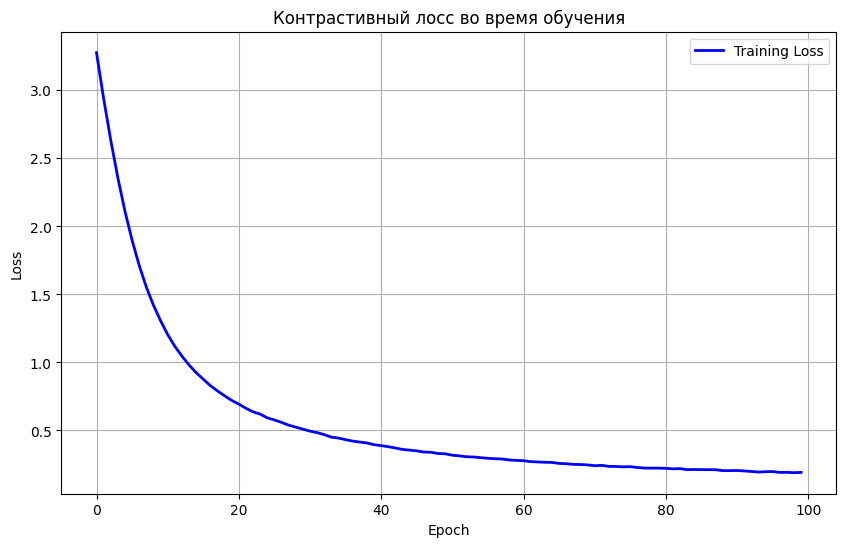

In [110]:
import matplotlib.pyplot as plt

def plot_training_loss(losses):
    """Визуализация процесса обучения"""
    plt.figure(figsize=(10, 6))
    plt.plot(losses, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Контрастивный лосс во время обучения')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_loss(training_losses)

Такие значения метрик получились и сильно превосходят случайный бейзлайн

In [111]:
for metric in model_results.keys():
    model_acc = model_results[metric]
    baseline_acc = baseline_results[metric]
    improvement = model_acc - baseline_acc
    improvement_pct = (improvement / baseline_acc) * 100

    print(f"   - {metric}:")
    print(f"     Модель: {model_acc:.4f}")
    print(f"     Бейзлайн: {baseline_acc:.4f}")
    print(f"     Улучшение: +{improvement:.4f} ({improvement_pct:.1f}%)")

   - accuracy@1:
     Модель: 0.2768
     Бейзлайн: 0.0020
     Улучшение: +0.2747 (13600.0%)
   - accuracy@3:
     Модель: 0.4727
     Бейзлайн: 0.0061
     Улучшение: +0.4667 (7700.0%)
   - accuracy@10:
     Модель: 0.7677
     Бейзлайн: 0.0202
     Улучшение: +0.7475 (3700.0%)


Не экспериментировал с числом эпох и размером батча, могу только рассказать, что пробовал перед тем, как запускать на полтора часа эмбединги и прогон модели на всём трэйне, сначала на небольшом вал куске отработать, а метрики замерять на тесте, и там уже были хорошие результаты accuracy в районе 0.3, 0.5, 0.7 (для 1, 3, 10) - уже сильно лучше случайного бэйзлайна

Милая мотивация ассистентам/лекторам, которым проверять гору решений домашек из совместного творчества бестолковых студентов с ещё более бестолковыми нейронками:

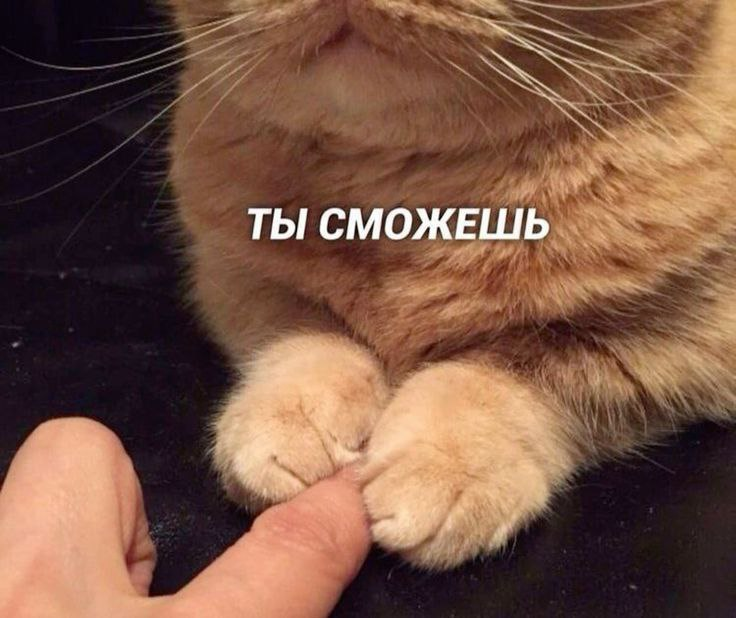

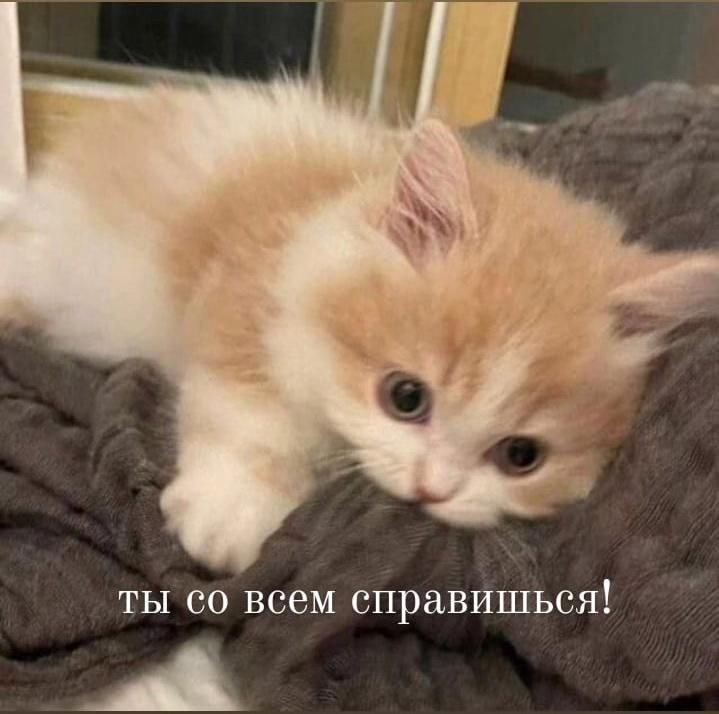

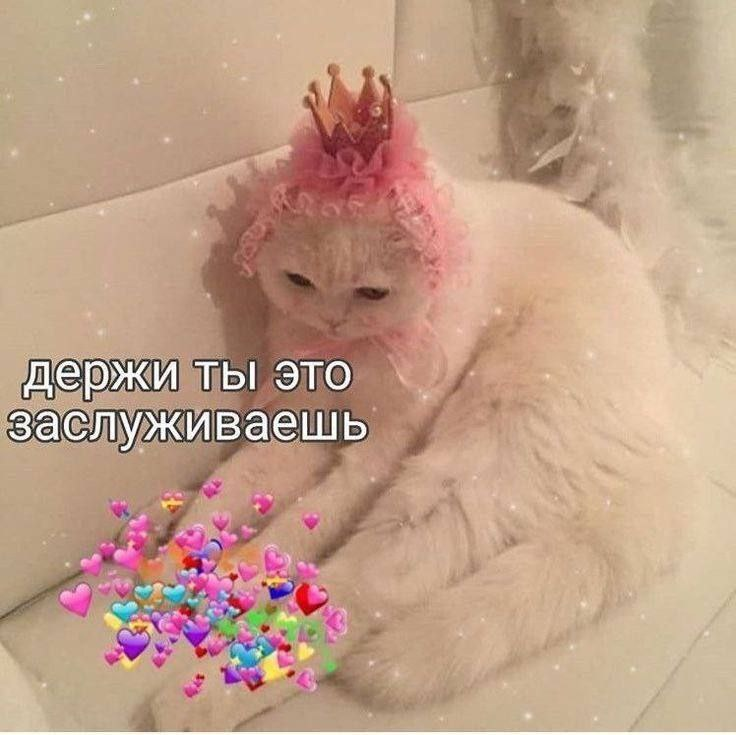